# Base 5 — ouro semanal: pipeline absoluta SARIMAX

Adaptação direta de `references/atividade_sarimax.ipynb`. O modo completo testa Base Models, SARIMA e SARIMAX, com sazonalidades inteiras de `s=0` até `s=100`.

## 1. Carregamento e validação da série

In [1]:
import itertools
import json
import platform
import os
import sys
import tempfile
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

BASE_NUMBER = 5
BASE_NAME = 'ouro semanal'
TIME_COL = 'DATE'
TARGET_COL = 'target_log_return_t_plus_1'
PRIMARY_EXOG_COL = 'treasury_10y_t'
FREQUENCY = 'W-FRI'
TRAIN_RATIO = 0.75
REFERENCE_PERIOD = 52
CALENDAR_KIND = 'month'
RANDOM_STATE = 42
N_FOLDS = 3
VALIDATION_HORIZON = max(4, min(24, REFERENCE_PERIOD))
ALPHA = 0.05
MAXITER = 100
PRINT_EVERY_CANDIDATE = True

# Segurança operacional: valide primeiro no modo reduzido. Troque para False
# somente quando quiser disparar a busca absoluta de s=0 até s=100.
SMOKE_TEST = os.getenv('SARIMAX_SMOKE_TEST', '0') == '1'
RUN_LABEL = "smoke" if SMOKE_TEST else "full"
CHECKPOINT_DIR = Path(tempfile.gettempdir()) / "trabalho_daniel_sarimax" / f"base_{BASE_NUMBER:02d}" / RUN_LABEL
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if SMOKE_TEST:
    P_VALUES, D_VALUES, Q_VALUES = [0], [1], [0]
    SP_VALUES, SD_VALUES, SQ_VALUES = [0, 1], [0], [0]
    S_VALUES = [0, 1, min(4, REFERENCE_PERIOD)]
    TREND_VALUES = ["n"]
else:
    P_VALUES, D_VALUES, Q_VALUES = [0, 1, 2, 3], [0, 1], [0, 1, 2, 3]
    SP_VALUES, SD_VALUES, SQ_VALUES = [0, 1, 2], [0, 1], [0, 1, 2]
    S_VALUES = list(range(0, 101))
    TREND_VALUES = ["n", "c", "t"]

EXOG_SETS = {
    "exog_principal": ["temperatura"],
    "calendario": ["feriado"],
    "exog_calendario": ["temperatura", "feriado"],
    "exog_calendario_dezembro": ["temperatura", "feriado", "dezembro"],
}
np.random.seed(RANDOM_STATE)
print("Base:", BASE_NUMBER, BASE_NAME)
print("Modo:", "TESTE REDUZIDO" if SMOKE_TEST else "BUSCA ABSOLUTA s=0..100")
print("Checkpoints temporários:", CHECKPOINT_DIR)
print("Python:", platform.python_version(), "| pandas:", pd.__version__)

Base: 5 ouro semanal
Modo: TESTE REDUZIDO
Checkpoints temporários: C:\Users\MATHEU~1\AppData\Local\Temp\trabalho_daniel_sarimax\base_05\smoke
Python: 3.11.2 | pandas: 3.0.6


In [2]:
def encontrar_raiz():
    atual = Path.cwd().resolve()
    for raiz in [atual, *atual.parents]:
        if (raiz / 'data').is_dir(): return raiz
    raise FileNotFoundError('Raiz do projeto não encontrada.')

ROOT = encontrar_raiz()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from series_temporais.data import ALVO_CANONICO, preparar_modelagem_ouro
from series_temporais.validation import validate_prediction_contract, validate_prediction_frame

DATA_PATH = ROOT / 'data' / f'base_{BASE_NUMBER:02d}' / 'raw.csv'
if not DATA_PATH.exists(): raise FileNotFoundError(DATA_PATH)
raw = pd.read_csv(DATA_PATH, low_memory=False)
weekly, model_df, feature_columns, train_model, test_model = preparar_modelagem_ouro(
    raw, regra_semanal=FREQUENCY, proporcao_treino=TRAIN_RATIO,
)
df = pd.DataFrame({
    'target_time': pd.to_datetime(model_df['target_date']).to_numpy(),
    'vendas': model_df[ALVO_CANONICO].to_numpy(dtype=float),
    'temperatura': model_df['treasury_10y_t'].to_numpy(dtype=float),
    'feriado': model_df['target_week_sin'].to_numpy(dtype=float),
    'dezembro': model_df['target_date'].dt.month.eq(12).astype(int).to_numpy(),
}, index=pd.DatetimeIndex(model_df['DATE'], name='origin_time'))
df_train = df.loc[pd.DatetimeIndex(train_model['DATE'])].copy()
df_test = df.loc[pd.DatetimeIndex(test_model['DATE'])].copy()
TEST_SIZE = len(df_test)
assert TARGET_COL == ALVO_CANONICO
assert len(df_train) == 1758
assert len(df_test) == len(test_model) == 586
assert df_train.target_time.max() <= df_test.index.min()
assert df_test.target_time.sub(df_test.index.to_series()).eq(pd.Timedelta(days=7)).all()
if not df.index.is_monotonic_increasing or df.index.has_duplicates:
    raise AssertionError('Índice temporal inválido.')
if df[['vendas', 'temperatura', 'feriado', 'dezembro']].isna().any().any():
    raise AssertionError('Valores ausentes após preparação.')

print('Arquivo:', DATA_PATH)
print('Alvo:', TARGET_COL, '| grade:', FREQUENCY)
print('Período das origens:', df.index.min(), 'até', df.index.max(), '| observações:', len(df))
display(df.head())
display(df.describe().T)

vif_frame = df[['temperatura', 'feriado', 'dezembro']].astype(float)
vif = pd.DataFrame({'variavel': vif_frame.columns,
                    'VIF': [variance_inflation_factor(vif_frame.values, i) for i in range(vif_frame.shape[1])]})
display(vif)


Arquivo: C:\Users\matheuscastilho-ieg\Downloads\trabalho-daniel-modelos\data\base_05\raw.csv
Alvo: target_log_return_t_plus_1 | grade: W-FRI
Período das origens: 1969-05-09 00:00:00 até 2014-04-04 00:00:00 | observações: 2344


,target_time,vendas,temperatura,feriado,dezembro
origin_time,,,,,
1969-05-09,1969-05-16,-0.002296,6.20,0.663123,0
1969-05-16,1969-05-23,-0.001150,6.26,0.568065,0
1969-05-23,1969-05-30,0.000000,6.36,0.464723,0
1969-05-30,1969-06-06,-0.064155,6.36,0.354605,0
1969-06-06,1969-06-13,0.019442,6.54,0.239316,0


,count,mean,min,25%,50%,75%,max,std
target_time,2344,1991-10-28 12:00:00,1969-05-16 00:00:00,1980-08-06 06:00:00,1991-10-28 12:00:00,2003-01-18 18:00:00,2014-04-11 00:00:00,NaN
vendas,2344.0,0.001452,-0.18058,-0.009391,0.0,0.012152,0.30253,0.027848
temperatura,2344.0,6.844663,1.45,4.73,6.69,8.2325,15.75,2.828312
feriado,2344.0,-0.001036,-1.0,-0.663123,0.0,0.663123,1.0,0.705813
dezembro,2344.0,0.084898,0.0,0.0,0.0,0.0,1.0,0.278789


,variavel,VIF
0,temperatura,1.000307
1,feriado,1.007444
2,dezembro,1.007740


## 2. Autocovariância, autocorrelação, ACF/PACF, ADF e KPSS

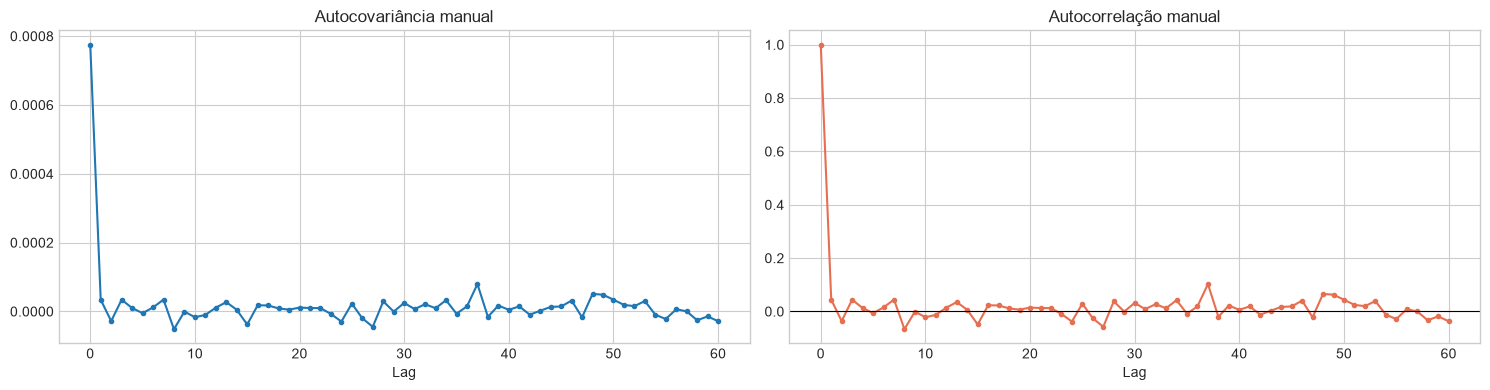

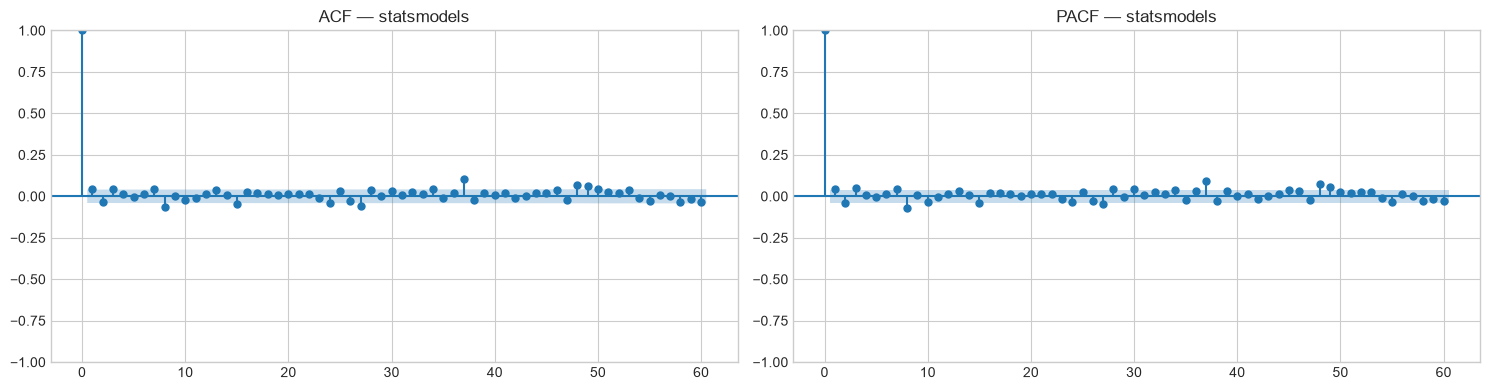

In [3]:
def autocovariance(series, lag):
    values = np.asarray(series, dtype=float)
    n = len(values)
    mean = values.mean()
    if lag < 0 or lag >= n:
        raise ValueError("Lag fora do intervalo da série.")
    return np.sum((values[lag:] - mean) * (values[: n - lag] - mean)) / n

def autocorrelation(series, lag):
    return autocovariance(series, lag) / autocovariance(series, 0)

serie_vendas = df["vendas"]
max_lag = min(60, len(serie_vendas) // 2 - 1)
lags = np.arange(max_lag + 1)
autocov_manual = [autocovariance(serie_vendas, lag) for lag in lags]
autocorr_manual = [autocorrelation(serie_vendas, lag) for lag in lags]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(lags, autocov_manual, marker="o", markersize=3)
axes[0].set_title("Autocovariância manual")
axes[0].set_xlabel("Lag")
axes[1].plot(lags, autocorr_manual, marker="o", markersize=3, color="#e76f51")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Autocorrelação manual")
axes[1].set_xlabel("Lag")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(serie_vendas, lags=max_lag, ax=axes[0], title="ACF — statsmodels")
plot_pacf(serie_vendas, lags=max_lag, ax=axes[1], method="ywm", title="PACF — statsmodels")
plt.tight_layout()
plt.show()


In [4]:
def adf_test(series, alpha=0.05):
    result = adfuller(pd.Series(series).dropna(), autolag="AIC")
    output = {
        "estatistica": result[0], "p_valor": result[1], "lags": result[2],
        "observacoes": result[3], "valores_criticos": result[4],
        "estacionaria": result[1] < alpha,
    }
    print("ADF")
    print(f"  Estatística: {output['estatistica']:.6f}")
    print(f"  p-valor: {output['p_valor']:.6f}")
    print("  Valores críticos:", output["valores_criticos"])
    return output

def kpss_test(series, alpha=0.05):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = kpss(pd.Series(series).dropna(), regression="c", nlags="auto")
    output = {
        "estatistica": result[0], "p_valor": result[1], "lags": result[2],
        "valores_criticos": result[3], "estacionaria": result[1] > alpha,
    }
    print("KPSS")
    print(f"  Estatística: {output['estatistica']:.6f}")
    print(f"  p-valor: {output['p_valor']:.6f}")
    print("  Valores críticos:", output["valores_criticos"])
    return output

resultado_adf = adf_test(serie_vendas, ALPHA)
resultado_kpss = kpss_test(serie_vendas, ALPHA)
estacionaria = resultado_adf["estacionaria"] and resultado_kpss["estacionaria"]
print("SÉRIE ESTACIONÁRIA" if estacionaria else "SÉRIE NÃO ESTACIONÁRIA")


ADF
  Estatística: -17.165305
  p-valor: 0.000000
  Valores críticos: {'1%': np.float64(-3.4331524402158027), '5%': np.float64(-2.862778064998932), '10%': np.float64(-2.567429076405341)}
KPSS
  Estatística: 0.227836
  p-valor: 0.100000
  Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
SÉRIE ESTACIONÁRIA


C:\Users\matheuscastilho-ieg\AppData\Local\Temp\ipykernel_5096\1317436872.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")


## 3. Separação temporal entre treino e teste

Treino: 1969-05-09 00:00:00 até 2003-01-10 00:00:00 1758
Teste : 2003-01-17 00:00:00 até 2014-04-04 00:00:00 586


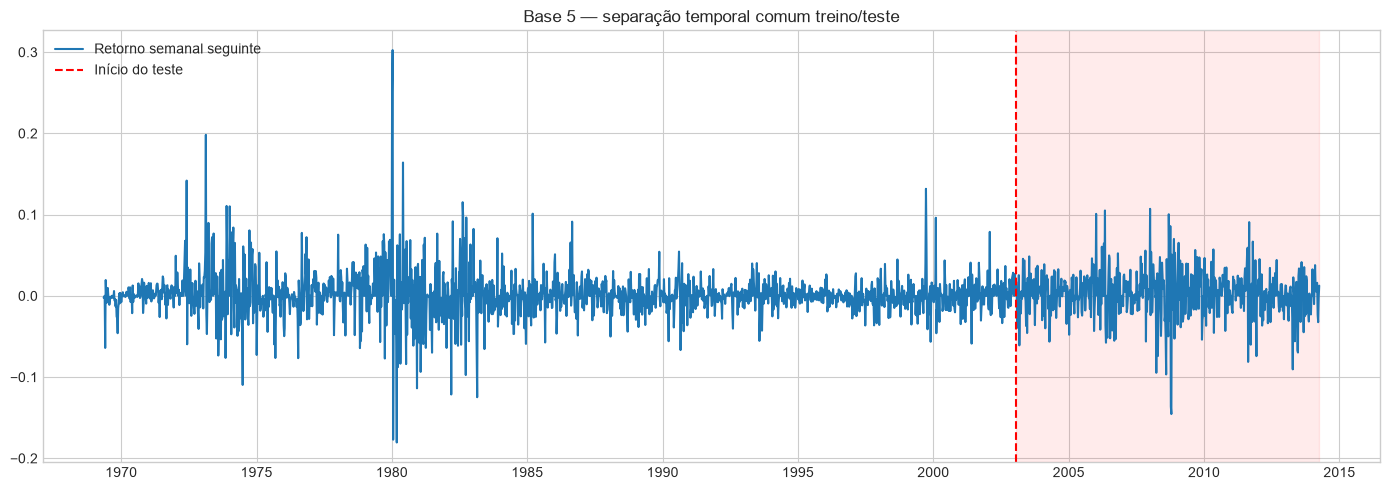

In [5]:
if df_train.empty or df_test.empty: raise AssertionError('Treino ou teste vazio.')
print('Treino:', df_train.index.min(), 'até', df_train.index.max(), len(df_train))
print('Teste :', df_test.index.min(), 'até', df_test.index.max(), len(df_test))

plt.figure(figsize=(14, 5)); plt.plot(df.index, df['vendas'], label='Retorno semanal seguinte')
plt.axvline(df_test.index[0], color='red', linestyle='--', label='Início do teste')
plt.axvspan(df_test.index[0], df_test.index[-1], color='red', alpha=0.08)
plt.title('Base 5 — separação temporal comum treino/teste'); plt.legend(); plt.tight_layout(); plt.show()

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true,float), np.asarray(y_pred,float); mask = y_true != 0
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100 if mask.any() else np.nan
def metrics(y_true, y_pred):
    return {"mae":float(mean_absolute_error(y_true,y_pred)),"mape":float(mape_safe(y_true,y_pred))}
def scale_exog(train_exog, other_exog):
    a,b=train_exog.astype(float).copy(),other_exog.astype(float).copy(); scaler=None
    continuous=[c for c in ["temperatura"] if c in a.columns]
    if continuous:
        scaler=StandardScaler(); a.loc[:,continuous]=scaler.fit_transform(a[continuous]); b.loc[:,continuous]=scaler.transform(b[continuous])
    return a,b,scaler
def fit_sarimax_model(y, exog, order, seasonal_order, trend):
    started=time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model=SARIMAX(endog=y,exog=exog,order=tuple(order),seasonal_order=tuple(seasonal_order),trend=trend,enforce_stationarity=False,enforce_invertibility=False)
        result=model.fit(disp=False,maxiter=MAXITER)
    return result,bool(result.mle_retvals.get("converged",True)),time.perf_counter()-started," | ".join(str(w.message) for w in caught[:3])
def fit_and_forecast(train,future,order,seasonal_order,trend="n",exog_cols=None):
    exog_cols=list(exog_cols or [])
    if exog_cols: x_train,x_future,scaler=scale_exog(train[exog_cols],future[exog_cols])
    else: x_train=x_future=scaler=None
    result,converged,elapsed,warning_text=fit_sarimax_model(train["vendas"],x_train,order,seasonal_order,trend)
    forecast=result.get_forecast(steps=len(future),exog=x_future).predicted_mean; forecast.index=future.index
    return {"result":result,"forecast":forecast,"converged":converged,"elapsed":elapsed,"warning":warning_text,"scaler":scaler}

## 4. Comparação inicial: SARIMA × SARIMAX com exógenas

,modelo,order,seasonal_order,exogenas,BIC,MAE_validacao,MAPE_validacao,convergiu
1,SARIMAX_exog_calendario,"(0, 1, 0)","(0, 0, 0, 0)","[temperatura, feriado]",-6387.699935,0.016487,405.456415,True
2,SARIMAX_exog_calendario_dezembro,"(0, 1, 0)","(0, 0, 0, 0)","[temperatura, feriado, dezembro]",-6380.275944,0.016632,407.705034,True
0,SARIMA_sem_exog,"(0, 1, 0)","(0, 0, 0, 0)",nenhuma,-6402.568056,0.016692,423.841214,True


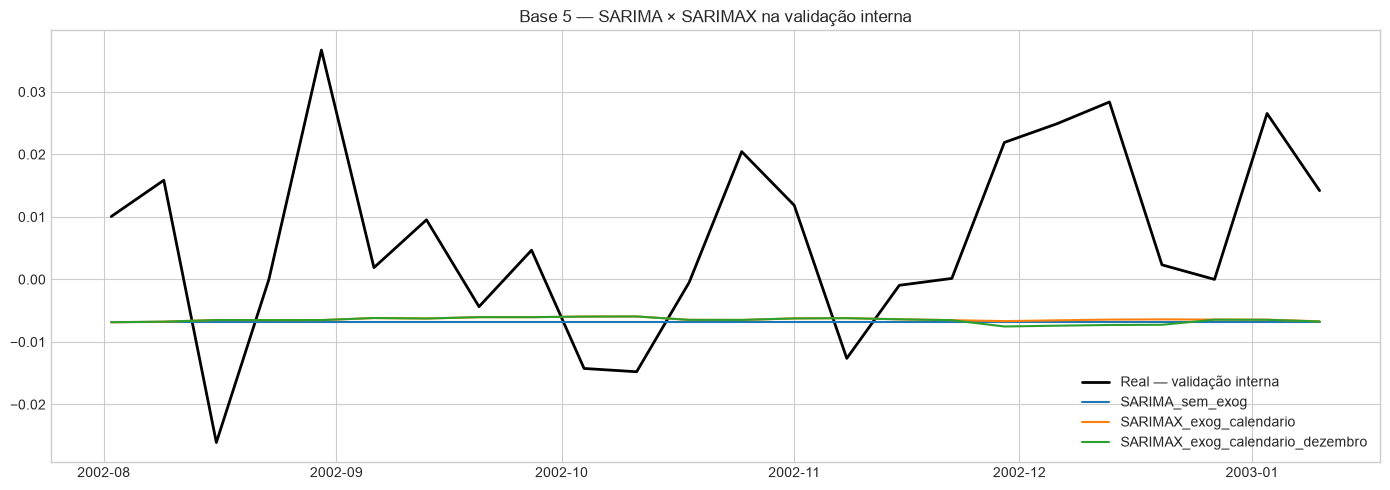

In [6]:
BENCHMARK_ORDER = (0, 1, 0) if SMOKE_TEST else (0, 1, 2)
BENCHMARK_SEASONAL = (0, 0, 0, 0) if SMOKE_TEST else (0, 1, 1, REFERENCE_PERIOD)
benchmark_specs = [
    ('SARIMA_sem_exog', []),
    ('SARIMAX_exog_calendario', ['temperatura', 'feriado']),
    ('SARIMAX_exog_calendario_dezembro', ['temperatura', 'feriado', 'dezembro']),
]
benchmark_train = df_train.iloc[:-VALIDATION_HORIZON].copy()
benchmark_validation = df_train.iloc[-VALIDATION_HORIZON:].copy()
assert benchmark_train.target_time.max() <= benchmark_validation.index.min()
benchmark_rows, benchmark_forecasts = [], {}
for model_name, exog_cols in benchmark_specs:
    fitted = fit_and_forecast(
        benchmark_train, benchmark_validation,
        BENCHMARK_ORDER, BENCHMARK_SEASONAL, 'n', exog_cols,
    )
    score = metrics(benchmark_validation['vendas'], fitted['forecast'])
    benchmark_rows.append({
        'modelo': model_name, 'order': BENCHMARK_ORDER,
        'seasonal_order': BENCHMARK_SEASONAL,
        'exogenas': exog_cols or 'nenhuma', 'BIC': fitted['result'].bic,
        'MAE_validacao': score['mae'], 'MAPE_validacao': score['mape'],
        'convergiu': fitted['converged'],
    })
    benchmark_forecasts[model_name] = fitted['forecast']
benchmark = pd.DataFrame(benchmark_rows).sort_values(['MAE_validacao', 'BIC'])
display(benchmark)
plt.figure(figsize=(14, 5))
plt.plot(benchmark_validation.index, benchmark_validation['vendas'],
         color='black', lw=2, label='Real — validação interna')
for name, forecast in benchmark_forecasts.items():
    plt.plot(benchmark_validation.index, forecast, label=name)
plt.title(f'Base {BASE_NUMBER} — SARIMA × SARIMAX na validação interna')
plt.legend(); plt.tight_layout(); plt.show()


## 5. Busca exaustiva: Base Models, SARIMA e SARIMAX

In [7]:
def validation_folds(n, n_folds=N_FOLDS, horizon=VALIDATION_HORIZON):
    initial = n - n_folds * horizon
    if initial <= 0:
        raise ValueError("Treino insuficiente para os folds solicitados.")
    return [(np.arange(0, initial + fold * horizon), np.arange(initial + fold * horizon, initial + (fold + 1) * horizon)) for fold in range(n_folds)]

FOLDS = validation_folds(len(df_train))
print("Folds temporais:")
for i, (train_idx, val_idx) in enumerate(FOLDS, 1):
    print(i, df_train.index[train_idx[0]].date(), "→", df_train.index[train_idx[-1]].date(), "| validação:", df_train.index[val_idx[0]].date(), "→", df_train.index[val_idx[-1]].date())

def json_default(value):
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, np.floating): return float(value)
    if isinstance(value, np.bool_): return bool(value)
    if isinstance(value, (tuple, set)): return list(value)
    if pd.isna(value): return None
    raise TypeError(f"Tipo não serializável: {type(value)}")

class ResultStore:
    def __init__(self, name):
        self.path = CHECKPOINT_DIR / f"{name}.jsonl"
        self.records, self.seen = [], set()
        if self.path.exists():
            with self.path.open("r", encoding="utf-8") as stream:
                for line in stream:
                    try:
                        record = json.loads(line)
                    except json.JSONDecodeError:
                        continue
                    self.records.append(record)
                    self.seen.add(record["candidate_key"])
            print(f"Retomando {name}: {len(self.records)} candidatos carregados.")
    def add(self, record):
        with self.path.open("a", encoding="utf-8") as stream:
            stream.write(json.dumps(record, ensure_ascii=False, default=json_default) + "\n")
        self.records.append(record)
        self.seen.add(record["candidate_key"])
    def frame(self):
        return pd.DataFrame(self.records)

def candidate_key(payload):
    return json.dumps(payload, sort_keys=True, ensure_ascii=False)

def print_candidate(record, current, total):
    if PRINT_EVERY_CANDIDATE:
        print(
            f"[{current:>7}/{total}] {record['family']:<10} status={record['status']:<15} "
            f"order={record.get('order')} seasonal={record.get('seasonal_order')} "
            f"exog={record.get('exog_key', 'nenhuma')} trend={record.get('trend', '-')} "
            f"MAE_val={record.get('val_mae')} BIC={record.get('bic')} "
            f"tempo={record.get('elapsed_seconds')}s erro={record.get('error', '')}"
        )

def sort_results(frame):
    if frame.empty: return frame
    ordered = frame.copy()
    ordered["_ok"] = ordered["status"].eq("ok")
    ordered["_mae"] = pd.to_numeric(ordered.get("val_mae"), errors="coerce").fillna(np.inf)
    ordered["_bic"] = pd.to_numeric(ordered.get("bic"), errors="coerce").fillna(np.inf)
    return ordered.sort_values(["_ok", "_mae", "_bic"], ascending=[False, True, True]).drop(columns=["_ok", "_mae", "_bic"]).reset_index(drop=True)

def print_full_ranking(frame, title):
    ranking = sort_results(frame)
    if not ranking.empty:
        ranking = ranking.copy()
        ranking.insert(0, "posicao", np.arange(1, len(ranking) + 1))
        ranking.insert(1, "destaque", ["MELHOR MODELO"] + [""] * (len(ranking) - 1))
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 260, "display.max_colwidth", 100):
        print(ranking.to_string(index=False))
    return ranking

def invalid_record(family, payload, error):
    return {
        "candidate_key": candidate_key(payload), "family": family, "status": "invalido",
        "order": payload.get("order"), "seasonal_order": payload.get("seasonal_order"),
        "s": payload.get("s"), "trend": payload.get("trend"),
        "exog_key": payload.get("exog_key", "nenhuma"), "exog_cols": payload.get("exog_cols", []),
        "val_mae": None, "val_mae_std": None, "val_mape": None, "bic": None, "aic": None,
        "converged": False, "elapsed_seconds": 0.0, "warning": "", "error": error,
    }


Folds temporais:
1 1969-05-09 → 2001-08-24 | validação: 2001-08-31 → 2002-02-08
2 1969-05-09 → 2002-02-08 | validação: 2002-02-15 → 2002-07-26
3 1969-05-09 → 2002-07-26 | validação: 2002-08-02 → 2003-01-10


In [8]:
def base_candidates():
    yield {"model": "media_historica", "window": None}
    yield {"model": "mediana_historica", "window": None}
    for lag in [1, 2, 4, 13, 26, 52]: yield {"model": "naive", "lag": lag}
    for window in [4, 8, 13, 26, 52]:
        yield {"model": "media_movel", "window": window}
        yield {"model": "mediana_movel", "window": window}
    for lookback in [None, 13, 26, 52, 104]: yield {"model": "drift", "lookback": lookback}
    for s in S_VALUES: yield {"model": "seasonal_naive", "s": s}

def base_forecast(y_train, horizon, params):
    values, model = np.asarray(y_train, dtype=float), params["model"]
    if model == "media_historica": return np.repeat(values.mean(), horizon)
    if model == "mediana_historica": return np.repeat(np.median(values), horizon)
    if model == "media_movel":
        window = params["window"]
        if len(values) < window: raise ValueError("Histórico insuficiente para a janela.")
        return np.repeat(values[-window:].mean(), horizon)
    if model == "mediana_movel":
        window = params["window"]
        if len(values) < window: raise ValueError("Histórico insuficiente para a janela.")
        return np.repeat(np.median(values[-window:]), horizon)
    if model == "naive":
        lag = params["lag"]
        if len(values) < lag: raise ValueError("Histórico insuficiente para o lag.")
        pattern = values[-lag:]
        return np.array([pattern[i % lag] for i in range(horizon)])
    if model == "seasonal_naive":
        s = params["s"]
        if s == 0: raise ValueError("s=0 representa ausência de sazonalidade.")
        if s == 1: raise ValueError("s=1 não é sazonalidade aplicável.")
        if len(values) < s: raise ValueError("Histórico insuficiente para a sazonalidade.")
        pattern = values[-s:]
        return np.array([pattern[i % s] for i in range(horizon)])
    if model == "drift":
        lookback = params["lookback"]
        selected = values if lookback is None else values[-lookback:]
        if len(selected) < 2: raise ValueError("Histórico insuficiente para drift.")
        slope = (selected[-1] - selected[0]) / (len(selected) - 1)
        return selected[-1] + slope * np.arange(1, horizon + 1)
    raise ValueError(f"Base Model desconhecido: {model}")

def search_base_models():
    candidates, store = list(base_candidates()), ResultStore("base_models")
    total, started_all = len(candidates), time.perf_counter()
    for current, params in enumerate(candidates, 1):
        payload = {"family": "BASE", **params}
        key = candidate_key(payload)
        if key in store.seen: continue
        started = time.perf_counter()
        try:
            fold_mae, fold_mape = [], []
            for train_idx, val_idx in FOLDS:
                pred = base_forecast(df_train["vendas"].iloc[train_idx], len(val_idx), params)
                score = metrics(df_train["vendas"].iloc[val_idx], pred)
                fold_mae.append(score["mae"]); fold_mape.append(score["mape"])
            record = {
                "candidate_key": key, "family": "BASE", "status": "ok", "model": params["model"],
                "params": params, "order": None, "seasonal_order": None, "s": params.get("s"),
                "trend": None, "exog_key": "nenhuma", "exog_cols": [],
                "val_mae": float(np.mean(fold_mae)), "val_mae_std": float(np.std(fold_mae)),
                "val_mape": float(np.mean(fold_mape)), "bic": None, "aic": None,
                "converged": True, "elapsed_seconds": round(time.perf_counter() - started, 4),
                "warning": "", "error": "",
            }
        except Exception as exc:
            record = invalid_record("BASE", payload, str(exc))
            record.update({"model": params["model"], "params": params, "elapsed_seconds": round(time.perf_counter() - started, 4)})
        store.add(record); print_candidate(record, current, total)
    frame = store.frame()
    print(f"Tempo total Base Models: {time.perf_counter() - started_all:.2f}s")
    print_full_ranking(frame, "RANKING COMPLETO — BASE MODELS")
    return frame


In [9]:
def seasonal_combinations():
    for s in S_VALUES:
        if s == 0:
            yield (0, 0, 0, 0)
        else:
            for sp, sd, sq in itertools.product(SP_VALUES, SD_VALUES, SQ_VALUES):
                yield (sp, sd, sq, s)

def statistical_candidate_count(exog_sets_count=1, trend_count=1):
    order_count = len(P_VALUES) * len(D_VALUES) * len(Q_VALUES)
    seasonal_count = sum(1 for _ in seasonal_combinations())
    return order_count * seasonal_count * exog_sets_count * trend_count

def statistical_candidates(family):
    exog_items, trends = ([("nenhuma", [])], ["n"]) if family == "SARIMA" else (list(EXOG_SETS.items()), TREND_VALUES)
    for p, d, q in itertools.product(P_VALUES, D_VALUES, Q_VALUES):
        order = (p, d, q)
        for seasonal_order in seasonal_combinations():
            for exog_key, exog_cols in exog_items:
                for trend in trends:
                    yield {
                        "family": family, "order": order, "seasonal_order": seasonal_order,
                        "s": seasonal_order[3], "exog_key": exog_key,
                        "exog_cols": exog_cols, "trend": trend,
                    }

def evaluate_statistical_candidate(payload):
    family, order = payload["family"], tuple(payload["order"])
    seasonal_order, s = tuple(payload["seasonal_order"]), payload["s"]
    exog_cols, trend = list(payload["exog_cols"]), payload["trend"]
    if s == 1:
        return invalid_record(family, payload, "s=1 auditado, mas não representa periodicidade sazonal válida no statsmodels.")
    started, fold_mae, fold_mape, convergences, warning_messages = time.perf_counter(), [], [], [], []
    try:
        for train_idx, val_idx in FOLDS:
            fold_train, fold_val = df_train.iloc[train_idx], df_train.iloc[val_idx]
            if exog_cols: x_train, x_val, _ = scale_exog(fold_train[exog_cols], fold_val[exog_cols])
            else: x_train = x_val = None
            result, converged, _, warning_text = fit_sarimax_model(fold_train["vendas"], x_train, order, seasonal_order, trend)
            pred = result.get_forecast(steps=len(fold_val), exog=x_val).predicted_mean
            score = metrics(fold_val["vendas"], pred)
            fold_mae.append(score["mae"]); fold_mape.append(score["mape"]); convergences.append(converged)
            if warning_text: warning_messages.append(warning_text)
        if exog_cols:
            x_full_train = df_train[exog_cols].astype(float).copy()
            continuous = [c for c in ["temperatura"] if c in exog_cols]
            if continuous:
                scaler = StandardScaler()
                x_full_train.loc[:, continuous] = scaler.fit_transform(x_full_train[continuous])
        else: x_full_train = None
        full_result, full_converged, _, full_warning = fit_sarimax_model(df_train["vendas"], x_full_train, order, seasonal_order, trend)
        if full_warning: warning_messages.append(full_warning)
        all_converged = bool(all(convergences) and full_converged)
        return {
            "candidate_key": candidate_key(payload), "family": family,
            "status": "ok" if all_converged else "nao_convergiu",
            "order": list(order), "seasonal_order": list(seasonal_order), "s": s,
            "trend": trend, "exog_key": payload["exog_key"], "exog_cols": exog_cols,
            "val_mae": float(np.mean(fold_mae)), "val_mae_std": float(np.std(fold_mae)),
            "val_mape": float(np.mean(fold_mape)), "bic": float(full_result.bic),
            "aic": float(full_result.aic), "converged": all_converged,
            "elapsed_seconds": round(time.perf_counter() - started, 4),
            "warning": " | ".join(warning_messages[:3]), "error": "",
        }
    except Exception as exc:
        record = invalid_record(family, payload, str(exc))
        record["status"] = "erro"
        record["elapsed_seconds"] = round(time.perf_counter() - started, 4)
        return record

def search_statistical_models(family):
    if family == "SARIMA":
        total, store_name = statistical_candidate_count(), "sarima"
    else:
        total, store_name = statistical_candidate_count(len(EXOG_SETS), len(TREND_VALUES)), "sarimax"
    print(f"\n{family}: total esperado de candidatos = {total:,}")
    store, started_all = ResultStore(store_name), time.perf_counter()
    for current, payload in enumerate(statistical_candidates(family), 1):
        if candidate_key(payload) in store.seen: continue
        record = evaluate_statistical_candidate(payload)
        store.add(record); print_candidate(record, current, total)
    frame = store.frame()
    successes, failures = int(frame["status"].eq("ok").sum()), int((~frame["status"].eq("ok")).sum())
    print(f"{family}: esperado={total:,}, registrado={len(frame):,}, sucessos={successes:,}, falhas/inválidos={failures:,}")
    if len(frame) != total: raise AssertionError(f"Busca incompleta de {family}: {len(frame)} de {total}.")
    print(f"Tempo total {family}: {time.perf_counter() - started_all:.2f}s")
    print_full_ranking(frame, f"RANKING COMPLETO — {family}")
    return frame


## 6. Sazonalidades inteiras de s=0 até s=100

In [10]:
print("S_VALUES ativos:", S_VALUES)
print("Contagem SARIMA:", statistical_candidate_count())
print("Contagem SARIMAX:", statistical_candidate_count(len(EXOG_SETS), len(TREND_VALUES)))
if SMOKE_TEST: print("Validação reduzida ativa. Use SMOKE_TEST=False para executar integralmente s=0..100.")

S_VALUES ativos: [0, 1, 4]
Contagem SARIMA: 5
Contagem SARIMAX: 20
Validação reduzida ativa. Use SMOKE_TEST=False para executar integralmente s=0..100.


## 7. Execução candidato a candidato e tabelas completas ordenadas

In [11]:
base_results = search_base_models()
sarima_results = search_statistical_models("SARIMA")
sarimax_results = search_statistical_models("SARIMAX")


Retomando base_models: 26 candidatos carregados.
Tempo total Base Models: 0.00s

RANKING COMPLETO — BASE MODELS
 posicao      destaque                                                    candidate_key family   status             model                                         params order seasonal_order   s trend exog_key exog_cols  val_mae  val_mae_std    val_mape  bic  aic  converged  elapsed_seconds warning                                    error
       1 MELHOR MODELO         {"family": "BASE", "model": "media_movel", "window": 52}   BASE       ok       media_movel         {'model': 'media_movel', 'window': 52}  None           None NaN  None  nenhuma        [] 0.012946     0.001039  123.899353 None None       True           0.0028                                                 
       2                       {"family": "BASE", "model": "media_movel", "window": 26}   BASE       ok       media_movel         {'model': 'media_movel', 'window': 26}  None           None NaN  None  nenhuma

## 8. Vencedores, diagnóstico dos resíduos e rankings

In [12]:
def best_valid_row(frame, filters=None):
    selected = frame.copy()
    if filters:
        for col, value in filters.items():
            selected = selected[selected[col] == value]
    selected = sort_results(selected[selected['status'] == 'ok'])
    if selected.empty:
        raise RuntimeError(f'Nenhum candidato válido para filtros={filters}')
    return selected.iloc[0]

best_base = best_valid_row(base_results)
best_sarima = best_valid_row(sarima_results)
best_sarimax = best_valid_row(sarimax_results)

print('Vencedores congelados pela validação; o teste só será tocado no walk-forward final.')
display(pd.DataFrame([
    {'modelo': 'Base Model', 'configuracao': best_base['params'], 's': best_base.get('s'),
     'exogenas': 'nenhuma', 'BIC': np.nan, 'MAE_validacao': best_base['val_mae'],
     'DP_MAE_validacao': best_base['val_mae_std']},
    {'modelo': 'SARIMA', 'configuracao': {'order': best_sarima['order'],
     'seasonal_order': best_sarima['seasonal_order'], 'trend': best_sarima['trend']},
     's': best_sarima['s'], 'exogenas': 'nenhuma', 'BIC': best_sarima['bic'],
     'MAE_validacao': best_sarima['val_mae'], 'DP_MAE_validacao': best_sarima['val_mae_std']},
    {'modelo': 'SARIMAX', 'configuracao': {'order': best_sarimax['order'],
     'seasonal_order': best_sarimax['seasonal_order'], 'trend': best_sarimax['trend']},
     's': best_sarimax['s'], 'exogenas': best_sarimax['exog_cols'], 'BIC': best_sarimax['bic'],
     'MAE_validacao': best_sarimax['val_mae'], 'DP_MAE_validacao': best_sarimax['val_mae_std']},
]))

print('\nTOP 10 BASE MODELS'); display(sort_results(base_results).head(10))
print('\nTOP 10 SARIMA'); display(sort_results(sarima_results).head(10))
print('\nTOP 10 SARIMAX'); display(sort_results(sarimax_results).head(10))


Vencedores congelados pela validação; o teste só será tocado no walk-forward final.


,modelo,configuracao,s,exogenas,BIC,MAE_validacao,DP_MAE_validacao
0,Base Model,"{'model': 'media_movel', 'window': 52}",NaN,nenhuma,NaN,0.012946,0.001039
1,SARIMA,"{'order': [0, 1, 0], 'seasonal_order': [1, 0, ...",4.0,nenhuma,-6495.207688,0.017017,0.002332
2,SARIMAX,"{'order': [0, 1, 0], 'seasonal_order': [1, 0, ...",4.0,[feriado],-6487.738263,0.017023,0.002294



TOP 10 BASE MODELS


,candidate_key,family,status,model,params,order,seasonal_order,s,trend,exog_key,exog_cols,val_mae,val_mae_std,val_mape,bic,aic,converged,elapsed_seconds,warning,error
0,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 52}",None,None,NaN,None,nenhuma,[],0.012946,0.001039,123.899353,None,None,True,0.0028,,
1,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 26}",None,None,NaN,None,nenhuma,[],0.013046,0.001204,149.775534,None,None,True,0.0030,,
2,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 13}",None,None,NaN,None,nenhuma,[],0.013094,0.001201,123.597861,None,None,True,0.0033,,
3,"{""family"": ""BASE"", ""model"": ""media_historica"",...",BASE,ok,media_historica,"{'model': 'media_historica', 'window': None}",None,None,NaN,None,nenhuma,[],0.013177,0.001027,117.849785,None,None,True,0.0039,,
4,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 26}",None,None,NaN,None,nenhuma,[],0.013197,0.000946,191.681732,None,None,True,0.0048,,
5,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 52}",None,None,NaN,None,nenhuma,[],0.013207,0.000846,100.189735,None,None,True,0.0046,,
6,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 13}",None,None,NaN,None,nenhuma,[],0.013221,0.000835,99.689090,None,None,True,0.0049,,
7,"{""family"": ""BASE"", ""model"": ""mediana_historica...",BASE,ok,mediana_historica,"{'model': 'mediana_historica', 'window': None}",None,None,NaN,None,nenhuma,[],0.013231,0.000828,100.000000,None,None,True,0.0059,,
8,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 4}",None,None,NaN,None,nenhuma,[],0.014020,0.001416,179.914796,None,None,True,0.0035,,
9,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 8}",None,None,NaN,None,nenhuma,[],0.014986,0.001862,260.227345,None,None,True,0.0034,,



TOP 10 SARIMA


,candidate_key,family,status,order,seasonal_order,s,trend,exog_key,exog_cols,val_mae,val_mae_std,val_mape,bic,aic,converged,elapsed_seconds,warning,error
0,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,nenhuma,[],0.017017,0.002332,236.979396,-6495.207688,-6506.145856,True,1.0421,"No frequency information was provided, so infe...",
1,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,nenhuma,[],0.017037,0.002305,238.927591,-6508.897918,-6514.368711,True,0.8062,"No frequency information was provided, so infe...",
2,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,nenhuma,[],0.017037,0.002305,238.927591,-6508.897918,-6514.368711,True,0.7909,"No frequency information was provided, so infe...",
3,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,invalido,"[0, 1, 0]","[0, 0, 0, 1]",1,n,nenhuma,[],NaN,NaN,NaN,NaN,NaN,False,0.0000,,"s=1 auditado, mas não representa periodicidade..."
4,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,invalido,"[0, 1, 0]","[1, 0, 0, 1]",1,n,nenhuma,[],NaN,NaN,NaN,NaN,NaN,False,0.0000,,"s=1 auditado, mas não representa periodicidade..."



TOP 10 SARIMAX


,candidate_key,family,status,order,seasonal_order,s,trend,exog_key,exog_cols,val_mae,val_mae_std,val_mape,bic,aic,converged,elapsed_seconds,warning,error
0,"{""exog_cols"": [""feriado""], ""exog_key"": ""calend...",SARIMAX,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,calendario,[feriado],0.017023,0.002294,239.143556,-6487.738263,-6504.145515,True,1.3681,"No frequency information was provided, so infe...",
1,"{""exog_cols"": [""feriado""], ""exog_key"": ""calend...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,calendario,[feriado],0.017044,0.002268,241.084541,-6501.427236,-6512.368823,True,1.7543,"No frequency information was provided, so infe...",
2,"{""exog_cols"": [""feriado""], ""exog_key"": ""calend...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,calendario,[feriado],0.017044,0.002268,241.084541,-6501.427236,-6512.368823,True,2.0228,"No frequency information was provided, so infe...",
3,"{""exog_cols"": [""temperatura""], ""exog_key"": ""ex...",SARIMAX,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,exog_principal,[temperatura],0.017062,0.002357,231.150727,-6487.754828,-6504.162079,True,1.0083,"No frequency information was provided, so infe...",
4,"{""exog_cols"": [""temperatura"", ""feriado""], ""exo...",SARIMAX,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,exog_calendario,"[temperatura, feriado]",0.017069,0.002317,233.547052,-6480.285401,-6502.161737,True,1.3240,"No frequency information was provided, so infe...",
5,"{""exog_cols"": [""temperatura""], ""exog_key"": ""ex...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,exog_principal,[temperatura],0.017081,0.002323,233.621153,-6501.432992,-6512.374579,True,1.7733,"No frequency information was provided, so infe...",
6,"{""exog_cols"": [""temperatura""], ""exog_key"": ""ex...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,exog_principal,[temperatura],0.017081,0.002323,233.621153,-6501.432992,-6512.374579,True,1.7210,"No frequency information was provided, so infe...",
7,"{""exog_cols"": [""temperatura"", ""feriado""], ""exo...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,exog_calendario,"[temperatura, feriado]",0.017088,0.002284,235.411821,-6493.962313,-6510.374694,True,2.7623,"No frequency information was provided, so infe...",
8,"{""exog_cols"": [""temperatura"", ""feriado""], ""exo...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,exog_calendario,"[temperatura, feriado]",0.017088,0.002284,235.411821,-6493.962313,-6510.374694,True,2.3778,"No frequency information was provided, so infe...",
9,"{""exog_cols"": [""temperatura"", ""feriado"", ""deze...",SARIMAX,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,exog_calendario_dezembro,"[temperatura, feriado, dezembro]",0.017158,0.002257,243.867794,-6472.826471,-6500.171890,True,1.2240,"No frequency information was provided, so infe...",



SAZONALIDADES — SARIMA
 posicao  s  melhor_mae  mae_mediano   melhor_bic  modelos_validos  tempo_total
       1  4    0.017017     0.017027 -6508.897918                2       1.8330
       2  0    0.017037     0.017037 -6508.897918                1       0.8062


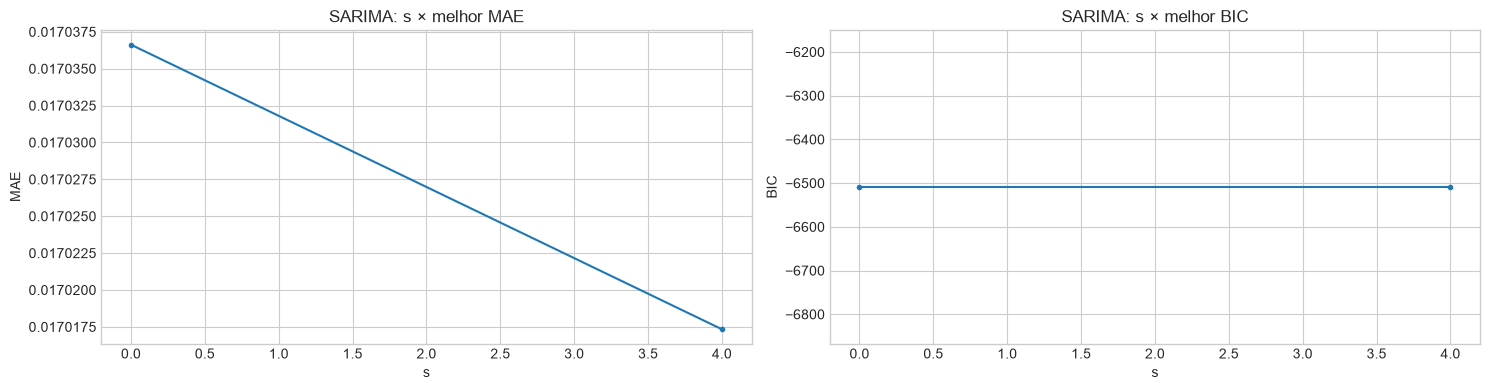


SAZONALIDADES — SARIMAX
 posicao  s  melhor_mae  mae_mediano   melhor_bic  modelos_validos  tempo_total
       1  4    0.017023     0.017075 -6501.432992                8      13.9196
       2  0    0.017044     0.017084 -6501.432992                4       8.6874


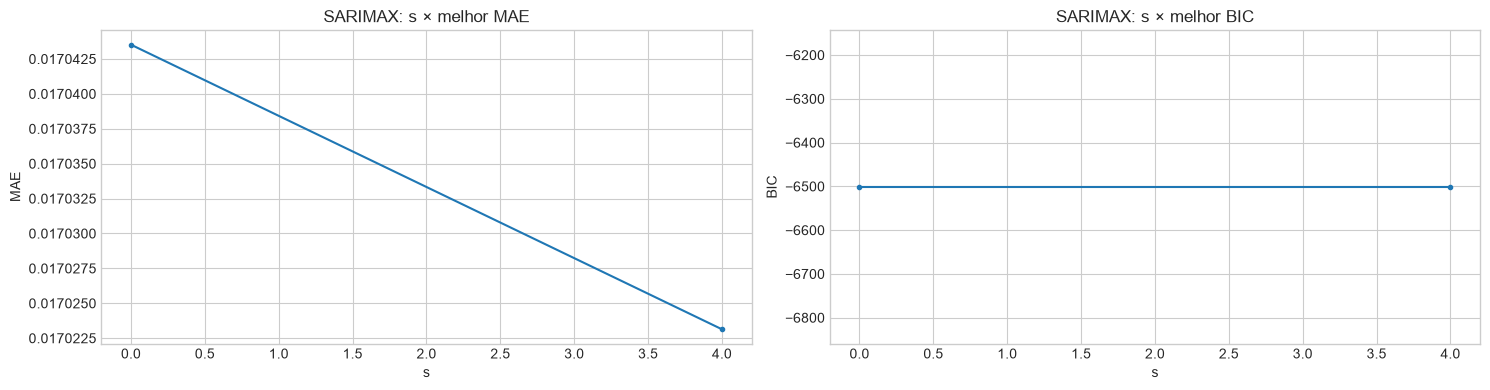

In [13]:
def seasonality_ranking(frame, family_name):
    valid = frame[frame["status"] == "ok"].copy()
    if valid.empty: return pd.DataFrame()
    summary = valid.groupby("s", dropna=False).agg(
        melhor_mae=("val_mae", "min"), mae_mediano=("val_mae", "median"),
        melhor_bic=("bic", "min"), modelos_validos=("candidate_key", "count"),
        tempo_total=("elapsed_seconds", "sum"),
    ).reset_index().sort_values(["melhor_mae", "melhor_bic"])
    summary.insert(0, "posicao", np.arange(1, len(summary) + 1))
    print(f"\nSAZONALIDADES — {family_name}")
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        print(summary.to_string(index=False))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(summary["s"], summary["melhor_mae"], marker="o", markersize=3)
    axes[0].set_title(f"{family_name}: s × melhor MAE"); axes[0].set_xlabel("s"); axes[0].set_ylabel("MAE")
    axes[1].plot(summary["s"], summary["melhor_bic"], marker="o", markersize=3)
    axes[1].set_title(f"{family_name}: s × melhor BIC"); axes[1].set_xlabel("s"); axes[1].set_ylabel("BIC")
    plt.tight_layout(); plt.show()
    return summary

sarima_seasonality = seasonality_ranking(sarima_results, "SARIMA")
sarimax_seasonality = seasonality_ranking(sarimax_results, "SARIMAX")


In [14]:
def residual_diagnostics(residuals, model_name, alpha=0.05):
    residuals = pd.Series(residuals).dropna().astype(float)
    lag = min(20, max(1, len(residuals) // 5))
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(residuals.to_numpy())
    axes[0, 0].axhline(0, color='black', linewidth=0.8)
    axes[0, 0].set_title(f'{model_name} — resíduos walk-forward')
    axes[0, 1].hist(residuals, bins=20, color='#457b9d', edgecolor='white')
    axes[0, 1].set_title(f'{model_name} — histograma')
    stats.probplot(residuals, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title(f'{model_name} — Q-Q')
    plot_acf(residuals, lags=lag, ax=axes[1, 1], title=f'{model_name} — ACF dos resíduos')
    plt.tight_layout(); plt.show()
    lb = acorr_ljungbox(residuals, lags=[lag], return_df=True)
    display(lb)
    pvalue = float(lb['lb_pvalue'].iloc[0])
    print('Resíduos compatíveis com ruído branco.' if pvalue > alpha else
          'Há autocorrelação significativa remanescente.')
    return {'media_residuos': float(residuals.mean()),
            'desvio_residuos': float(residuals.std()),
            'ljung_box_lag': lag, 'ljung_box_p': pvalue}


,modelo,alvo,MAE_teste,origens,horizonte,exogenas
0,Base Model,target_log_return_t_plus_1,0.020296,586,1 semana,NaN
1,SARIMA,target_log_return_t_plus_1,0.029213,586,1 semana,NaN
2,SARIMAX,target_log_return_t_plus_1,0.029219,586,1 semana,[feriado]


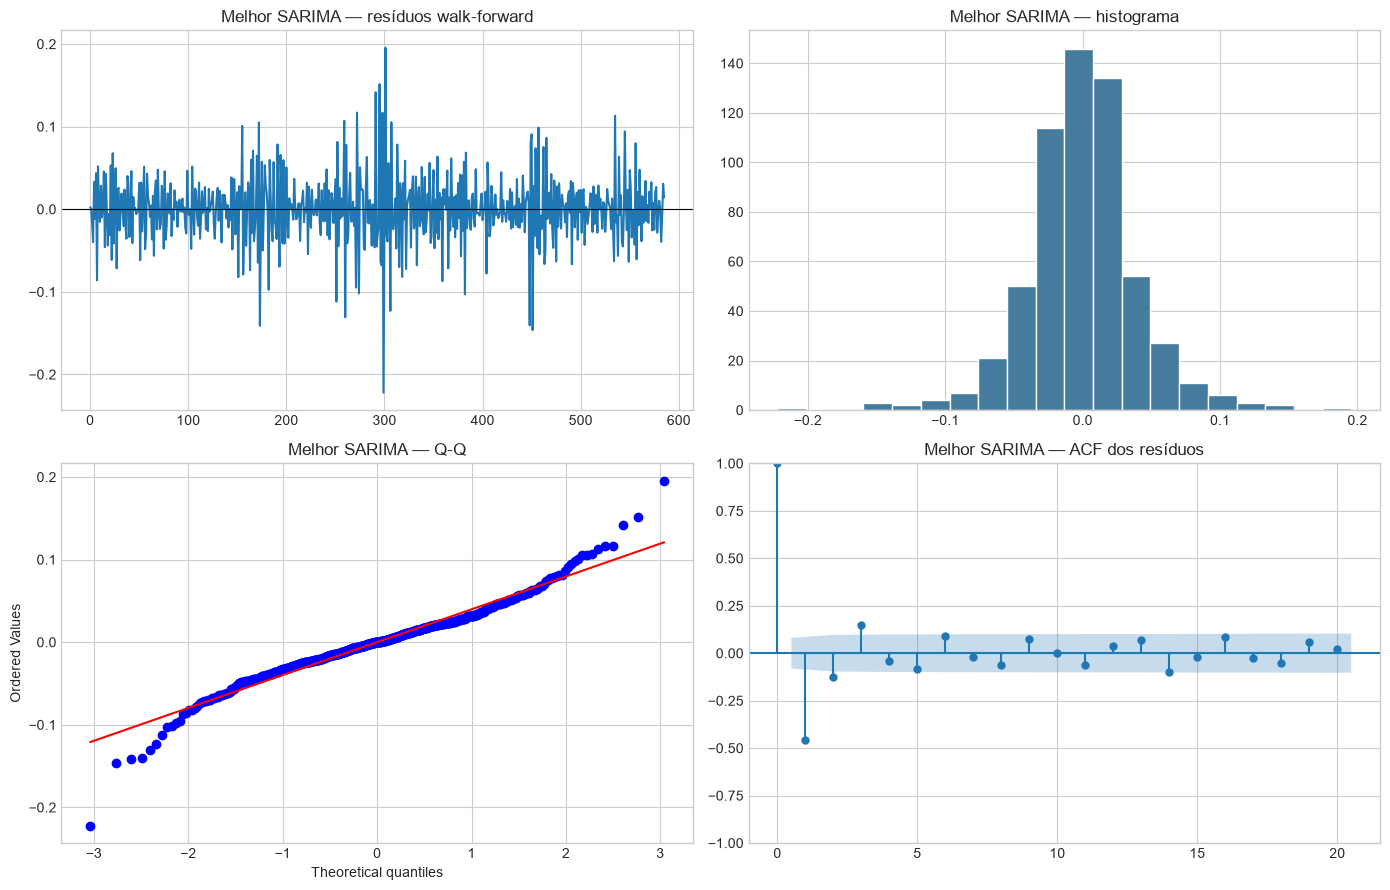

,lb_stat,lb_pvalue
20,183.841997,1.715473e-28


Há autocorrelação significativa remanescente.


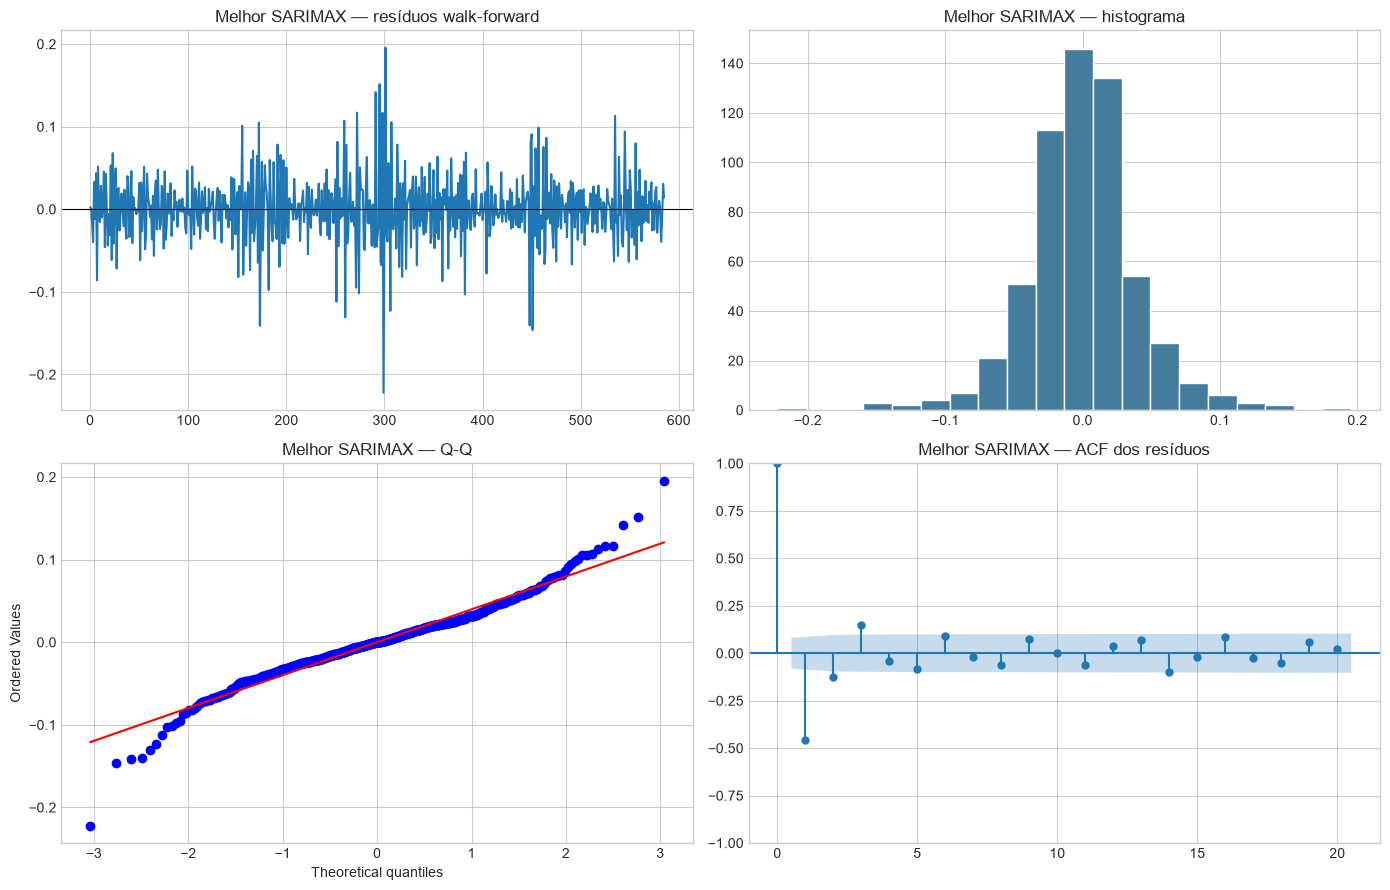

,lb_stat,lb_pvalue
20,183.849514,1.709659e-28


Há autocorrelação significativa remanescente.


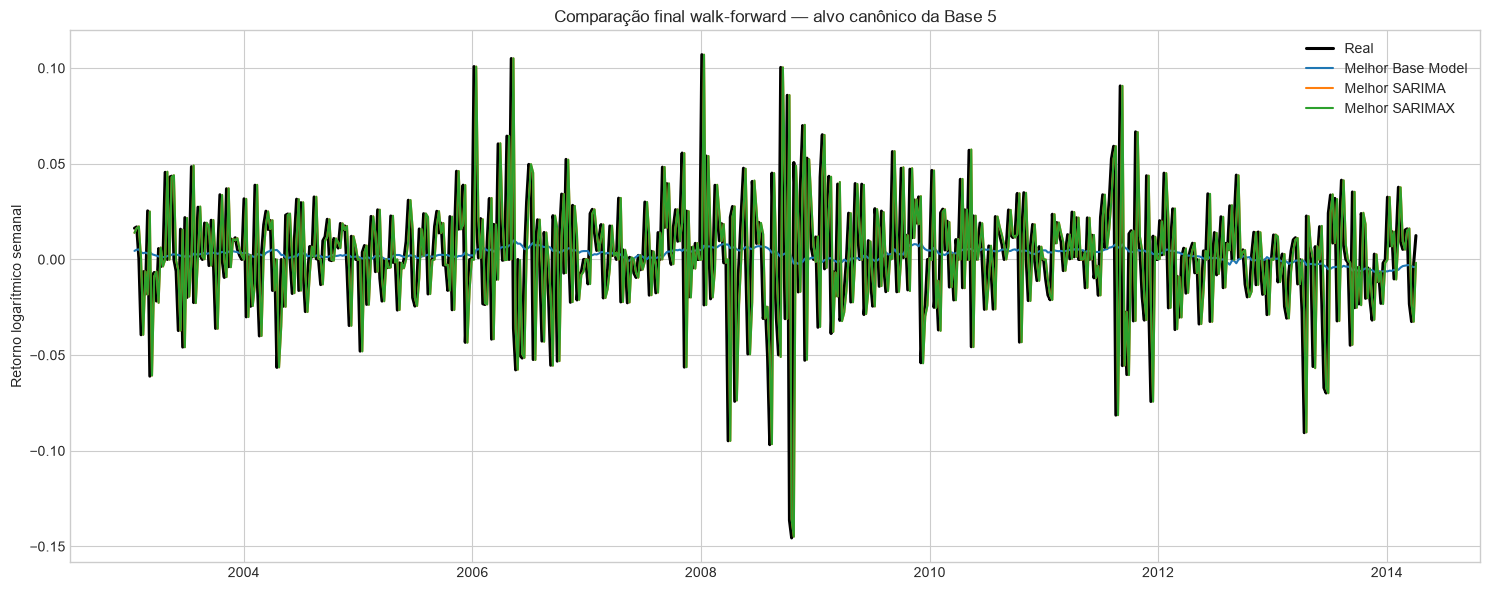

In [15]:
# TESTE FINAL CORRIGIDO — walk-forward de um passo, com reestimativa por origem
KNOWN_AT_ORIGIN_EXOG = {'temperatura', 'feriado', 'dezembro'}

def walk_forward_base_model(params):
    history = df_train.copy()
    rows = []
    for origin_time, row in df_test.iterrows():
        cutoff = pd.Timestamp(history['target_time'].max())
        prediction = float(base_forecast(history['vendas'].to_numpy(), 1, params)[0])
        rows.append({
            'origin_time': origin_time, 'target_time': row['target_time'],
            'y_true': float(row['vendas']), 'y_pred': prediction,
            'training_target_cutoff': cutoff,
        })
        history = pd.concat([history, row.to_frame().T.set_axis([origin_time])])
    frame = pd.DataFrame(rows)
    validate_prediction_frame(frame)
    return frame

def walk_forward_sarimax_model(best_row):
    requested = list(best_row['exog_cols'])
    exog_cols = [column for column in requested if column in KNOWN_AT_ORIGIN_EXOG]
    history = df_train.copy()
    rows, convergence, warnings_seen = [], [], []
    for origin_time, row in df_test.iterrows():
        cutoff = pd.Timestamp(history['target_time'].max())
        x_history = history[exog_cols].astype(float) if exog_cols else None
        result, converged, _, warning_text = fit_sarimax_model(
            history['vendas'].astype(float), x_history,
            tuple(best_row['order']), tuple(best_row['seasonal_order']), best_row['trend'],
        )
        x_future = row[exog_cols].astype(float).to_frame().T if exog_cols else None
        prediction = float(result.get_forecast(steps=1, exog=x_future).predicted_mean.iloc[0])
        rows.append({
            'origin_time': origin_time, 'target_time': row['target_time'],
            'y_true': float(row['vendas']), 'y_pred': prediction,
            'training_target_cutoff': cutoff,
        })
        convergence.append(converged)
        if warning_text: warnings_seen.append(warning_text)
        history = pd.concat([history, row.to_frame().T.set_axis([origin_time])])
    frame = pd.DataFrame(rows)
    validate_prediction_frame(frame)
    return frame, all(convergence), ' | '.join(warnings_seen[:3]), exog_cols

base_predictions = walk_forward_base_model(best_base['params'])
sarima_predictions, sarima_converged, sarima_warning, _ = walk_forward_sarimax_model(best_sarima)
sarimax_predictions, sarimax_converged, sarimax_warning, sarimax_exog = walk_forward_sarimax_model(best_sarimax)
for predictions in (base_predictions, sarima_predictions, sarimax_predictions):
    validate_prediction_contract(
        predictions, test_model, expected_target_col=ALVO_CANONICO,
    )
assert len(base_predictions) == len(sarima_predictions) == len(sarimax_predictions) == 586

base_forecast_test = pd.Series(base_predictions.y_pred.to_numpy(), index=df_test.index)
sarima_final = {'forecast': pd.Series(sarima_predictions.y_pred.to_numpy(), index=df_test.index)}
sarimax_final = {'forecast': pd.Series(sarimax_predictions.y_pred.to_numpy(), index=df_test.index)}
base_score = metrics(base_predictions.y_true, base_predictions.y_pred)
sarima_score = metrics(sarima_predictions.y_true, sarima_predictions.y_pred)
sarimax_score = metrics(sarimax_predictions.y_true, sarimax_predictions.y_pred)
comparison_final = pd.DataFrame([
    {'modelo': 'Base Model', 'alvo': TARGET_COL, 'MAE_teste': base_score['mae'], 'origens': len(base_predictions), 'horizonte': '1 semana'},
    {'modelo': 'SARIMA', 'alvo': TARGET_COL, 'MAE_teste': sarima_score['mae'], 'origens': len(sarima_predictions), 'horizonte': '1 semana'},
    {'modelo': 'SARIMAX', 'alvo': TARGET_COL, 'MAE_teste': sarimax_score['mae'], 'origens': len(sarimax_predictions), 'horizonte': '1 semana', 'exogenas': sarimax_exog},
]).sort_values('MAE_teste')
display(comparison_final)

for frame in (base_predictions, sarima_predictions, sarimax_predictions):
    frame['residual'] = frame.y_true - frame.y_pred

diag_sarima = residual_diagnostics(sarima_predictions.residual, 'Melhor SARIMA')
diag_sarimax = residual_diagnostics(sarimax_predictions.residual, 'Melhor SARIMAX')

plt.figure(figsize=(15, 6))
plt.plot(df_test.index, df_test['vendas'], color='black', linewidth=2.2, label='Real')
plt.plot(df_test.index, base_predictions.y_pred, label='Melhor Base Model')
plt.plot(df_test.index, sarima_predictions.y_pred, label='Melhor SARIMA')
plt.plot(df_test.index, sarimax_predictions.y_pred, label='Melhor SARIMAX')
plt.title('Comparação final walk-forward — alvo canônico da Base 5')
plt.ylabel('Retorno logarítmico semanal')
plt.legend(); plt.tight_layout(); plt.show()
